In [1]:
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.ticker as mtick

SCHEMES = [
        "../../DATA/SRF/Treshold=1/single-srcs-dsts",
        "../../DATA/SRF/Treshold=100000/single-srcs-dsts",
        # "../../DATA/SRF/Treshold=1000000/single-srcs-dsts",
        "../../DATA/SRF/Treshold=10000000/single-srcs-dsts",
        "../../DATA/SRF/Treshold=10000000000/single-srcs-dsts",
        ]
SCHEMES_label = [
                "阈值=1",
                r"阈值=$10^5$",
                # "Threshold=1e6",
                r"阈值=$10^7$",
                r"阈值=$10^{10}$",
                 ]
# SCHEMES = ['Zeropod/multipods_W5/select_core_according_to_flow_size_8_8_supress_c2e/W4_28_lower_ost/ppt_32_bppn_320_topk_16']
workloads = ["W5_0.1", "W5_0.25", "W5_0.5", "W5_0.75", "W5_1"]
labels = ["10", "25", "50", "75", "100"]

metrics = ['FCT', 'GOODPUT']
pod_scale = 25
# labels = ['10', '25', '50', '75', '100']
# labels = ['2', '3', '4', '5', '6']

my_figsize = [15, 10]
my_fontsize = 30
WIDTH = 0.05  # the width of the bars
SHORT = 100001-2  # 100KB
LONG = 1000000 # 1MB

data = {}
for scheme in SCHEMES:
    data[scheme] = {}
    for workload in workloads:
        data[scheme][workload] = {}

for scheme in SCHEMES:
    for workload in workloads:
        for metric in metrics:
            file_name = "{scheme}/DATA_{workload}/{metric}.txt".format(scheme=scheme, workload=workload, metric=metric)
            data[scheme][workload][metric] = np.loadtxt(file_name)

for scheme in SCHEMES:
        for workload in workloads:
            data[scheme][workload]['SHORT_IDX'] = data[scheme][workload]['FCT'][:, 4] < SHORT
            data[scheme][workload]['LONG_IDX'] = data[scheme][workload]['FCT'][:, 4] > LONG
            data[scheme][workload]['MIDDLE_IDX'] = (data[scheme][workload]['FCT'][:, 4] >= SHORT) * (data[scheme][workload]['FCT'][:, 4] <= LONG)
            data[scheme][workload]['singlepod'] = np.trunc(data[scheme][workload]['FCT'][:,2] / pod_scale) == np.trunc(data[scheme][workload]['FCT'][:,3] / pod_scale)
            data[scheme][workload]['multipods'] = np.trunc(data[scheme][workload]['FCT'][:,2] / pod_scale) != np.trunc(data[scheme][workload]['FCT'][:,3] / pod_scale)


In [8]:
# print(np.sum(data["old_schedule"]["W4_1"]["SHORT_IDX"]))
# print(np.sum(data["old_schedule"]["W4_1"]["MIDDLE_IDX"]))
# print(np.sum(data["old_schedule"]["W4_1"]["LONG_IDX"]))
# print(np.sum(data["old_schedule"]["W4_1"]["multipods"]))

In [9]:
# start_time = np.full(128, 100.0)
# end_time = np.full(128, 0.0)
# for scheme in SCHEMES:
#     for workload in workloads:
#         fct = data[scheme][workload]['FCT']
#         for i in range(fct.shape[0]):
#             if fct[i][6] < start_time[int(fct[i][3])]:
#                 start_time[int(fct[i][3])] = fct[i][6]
#             if fct[i][6] > end_time[int(fct[i][3])]:
#                 end_time[int(fct[i][3])] = fct[i][6]
# print(start_time)
# print(end_time)


In [2]:


bandwidth = [20, 30]
def goodput(labels, workload, ax, pods):

    results = {}
    for ii, scheme in enumerate(SCHEMES):
        results[scheme] = []
        for workload in workloads:
            # start_time = np.full(128, 100.0)
            # end_time = np.full(128, 0.0)
            start_time = np.full(128, 100.0)
            end_time = np.full(128, 0.0)
            
            fct = data[scheme][workload]['FCT']
            for i in range(fct.shape[0]):
                if fct[i][6] < start_time[int(fct[i][3])]:
                    start_time[int(fct[i][3])] = fct[i][6]
                if fct[i][6] > end_time[int(fct[i][3])]:
                    end_time[int(fct[i][3])] = fct[i][6]
            # if flow_range == 'Mice':
            #     idx = data[scheme][workload]['SHORT_IDX']
            # elif flow_range == 'Elephant':
            #     idx = data[scheme][workload]['LONG_IDX']
            # elif flow_range == 'middle':
            #     idx = data[scheme][workload]['MIDDLE_IDX']
            # elif flow_range == 'all':
            #     idx = np.arange(len(data[scheme][workload]['FCT']))
            # print(workload)
            if pods == 'singlepod':
                idx = data[scheme][workload]['singlepod']
            if pods == 'multipods':
                idx = data[scheme][workload]['multipods']

            fct =data[scheme][workload]['FCT'][idx, :]

            # start_time = np.full(128, 100.0)
            # end_time = np.full(128, 0.0)
            received_bytes = np.full(128, 0.0)
            # print(fct_single.shape[0])
            # print(fct_multi.shape[0])
            for i in range(fct.shape[0]):
                received_bytes[int(fct[i][3])] += fct[i][4]
                # if fct_single[i][6] < start_time[int(fct_single[i][3])]:
                #     start_time[int(fct_single[i][3])] = fct_single[i][6]
                # if fct_single[i][6] > end_time[int(fct_single[i][3])]:
                #     end_time[int(fct_single[i][3])] = fct_single[i][6]
            # print(received_bytes)
            results[scheme].append(np.mean(received_bytes * 8 / (end_time - start_time) / 1e9))
            
            # if pods == "multipods":
            #     results[scheme].append(np.mean(received_bytes * 8 / (end_time - start_time) / 1e9) / bandwidth[ii])
            # else:
            #     results[scheme].append(np.mean(received_bytes * 8 / (end_time - start_time) / 1e9) / (100 - bandwidth[ii]))

            # print(start_time)


            # start_time = np.full(128, 100.0)
            # end_time = np.full(128, 0.0)
            received_bytes_multi = np.full(128, 0.0)





    x_tick = np.arange(len(labels))*0.3 # the label locations
    x = x_tick - (len(SCHEMES)-1)*WIDTH/2

    # fig, ax = plt.subplots(figsize=my_figsize)
    # plt.figure()
    # fig, ax = plt.subplots(figsize=my_figsize)
    ax.grid(axis='y')
    for i, scheme in enumerate(SCHEMES):
        # ax.bar(x + WIDTH*i, results[scheme][mode], WIDTH, label=scheme)
        # 一次画一个scheme的所有load的bar
        # ax.bar(x + WIDTH*i, results_multi[scheme], WIDTH, edgecolor="black", label=SCHEMES_label[i], linewidth = 3, color=[colors[i]], hatch=hatches[i])
        # if i > 0:
        #     ax.bar(x + WIDTH*i, results[scheme], WIDTH, edgecolor="firebrick", color=[colors[i]], label=SCHEMES_label[i], hatch=hatches[i], linewidth = 3)
        # else:
        #     ax.bar(x + WIDTH*(i), results[scheme], WIDTH, edgecolor="darkblue", color=[colors[i]], label=SCHEMES_label[i], hatch=hatches[i], linewidth = 3)
        ax.bar(x + WIDTH*(i), results[scheme], WIDTH, edgecolor=edge_colors[i], color=[colors[i]], label=SCHEMES_label[i], hatch=hatches[i], linewidth = 3)
        

        # if mode == "Mean":
        #     ax.set_ylabel('Avg. FCT of ' + flow_range + " (ms)", fontsize=my_fontsize)
        # elif mode == "99p":
        #     ax.set_ylabel('99p FCT of ' + flow_range + " (ms)", fontsize=my_fontsize)
        # else:
        #     ax.set_ylabel('FCT of ' + flow_range + " (ms)", fontsize=my_fontsize)
        ax.set_ylabel('Goodput (Gbps)', fontsize=my_fontsize)
        # ax.set_ylabel('Normalized Goodput', fontsize=my_fontsize)

        ax.tick_params(axis='both', which='both', length=5, labelsize=my_fontsize)
        # ax.set_xlabel("Incast Degree", fontsize=my_fontsize)
        # ax.set_title('Accelerate by adding line rate', fontsize=my_fontsize)
        # ax.set_xlabel("Load (%)", fontsize=my_fontsize)
        ax.set_xticks(x_tick)

        plt.xticks(fontsize=my_fontsize)
        plt.yticks(fontsize=my_fontsize)


        ax.set_xticklabels(labels, fontsize=my_fontsize)

        # scientific_formatter = FuncFormatter(scientific)
        # ax.yaxis.set_major_formatter(scientific_formatter)
        # ax.yaxis.set_minor_formatter(mticker.ScalarFormatter())

        # ax.set_yscale('log')
        ax.ticklabel_format( style='plain', axis='y')

        # ax.set_yscale('log')

        # ax.set_ylim([0.0001,1000])
        ax.legend(ncol=1, loc = "upper left", fontsize=25)
        
        ax.spines['bottom'].set_linewidth(2.0)
        ax.spines['top'].set_linewidth(2.0)
        ax.spines['left'].set_linewidth(2.0)
        ax.spines['right'].set_linewidth(2.0)
        # ax.set_yscale('log')
        # ax.legend(ncol=2, loc = "upper left", fontsize=my_fontsize-2, handlelength=1.5, borderpad = 0.2, labelspacing = 0.3, columnspacing = 1.0)
        if pods == "singlepod":
            ax.set_title("Inside Pods", fontsize=my_fontsize+5)
        if pods == "multipods":
            ax.set_title("Across Pods", fontsize=my_fontsize+5)
        figure_path = '../FIGS/Zeropod/split goodput.pdf'
        # plt.savefig(figure_path, dpi=300, bbox_inches='tight')
        
# my_figsize = [24, 8]
# fig, axs = plt.subplots(1, 2, figsize=my_figsize)



In [11]:
def fct_bar_plot(mode, labels, workload, ax, flow_range='all', pods="all", unit='us'):

    results = {}
    for scheme in SCHEMES:
        results[scheme] = []
        for workload in workloads:
            if flow_range == 'Mice':
                idx = data[scheme][workload]['SHORT_IDX']
            elif flow_range == 'Elephant':
                idx = data[scheme][workload]['LONG_IDX']
            elif flow_range == 'middle':
                idx = data[scheme][workload]['MIDDLE_IDX']
            elif flow_range == 'all':
                idx = np.arange(len(data[scheme][workload]['FCT']))

            # available_idx = data[scheme][workload]['FCT'][:, 7] > 0 # 过滤未完成的流
            if pods == "singlepod":
                idx_xx = data[scheme][workload]['singlepod']
                idx = idx * idx_xx
            elif pods == "multipods":
                idx_xx = data[scheme][workload]['multipods']
                idx = idx * idx_xx
            # print(sum(idx_xx))
            # idx_xx = data[scheme][workload]['singlepod']
            
            print(sum(idx))

            fct = data[scheme][workload]['FCT'][idx, 7] # fct

            if mode == 'Mean':
                results[scheme].append(np.mean(fct) * 1e3)
            elif mode == 'Median':
                results[scheme].append(np.percentile(fct, 50) * 1e3)
            elif mode == '90p':
                results[scheme].append(np.percentile(fct, 90) * 1e3)
            elif mode == '99p':
                if unit == 'us':
                    results[scheme].append(np.percentile(fct, 99) * 1e6)
                else:
                    results[scheme].append(np.percentile(fct, 99) * 1e3)
            elif mode == '99.9p':
                if unit == 'us':
                    results[scheme].append(np.percentile(fct, 99.9) * 1e6)
                else:
                    results[scheme].append(np.percentile(fct, 99.9) * 1e3)

    print(results)


    # SCHEMES_label = ['OST_2', 'OST_3', 'OST_4', 'OST_5', 'OST_6']
    # SCHEMES_label = ['BPPN_250', 'BPPN_300', 'BPPN_350', 'BPPN_400',]
    # SCHEMES_label = ['BPPN_50', 'BPPN_100', 'BPPN_150', 'BPPN_200', 'BPPN_250']
    # SCHEMES_label = ['BPPN_10', 'BPPN_20', 'BPPN_30', 'BPPN_40', 'BPPN_50']
    # SCHEMES_label = SCHEMES




    x_tick = np.arange(len(labels))*0.3 # the label locations
    x = x_tick - (len(SCHEMES)-1)*WIDTH/2

    # fig, ax = plt.subplots(figsize=my_figsize)
    # fig, ax = plt.subplots(figsize=my_figsize)
    ax.grid(axis='y')
    # hatches = ["", ".", "\\", "x", "*", "|", "o"]
    # colors = ["white", "white", "white", "white", "white", "white", "white"]
    for i, scheme in enumerate(SCHEMES):
        # ax.bar(x + WIDTH*i, results[scheme][mode], WIDTH, label=scheme)
        # 一次画一个scheme的所有load的bar
        # ax.bar(x + WIDTH*i, results[scheme], WIDTH, edgecolor="black", label=SCHEMES_label[i], linewidth = 3, color=[colors[i]], hatch=hatches[i])
        # if i > 0:
        #     ax.bar(x + WIDTH*i, results[scheme], WIDTH, edgecolor="firebrick", color=[colors[i]], label=SCHEMES_label[i], hatch=hatches[i], linewidth = 3)
        # else:
        #     ax.bar(x + WIDTH*(i), results[scheme], WIDTH, edgecolor="darkblue", color=[colors[i]], label=SCHEMES_label[i], hatch=hatches[i], linewidth = 3)
        ax.bar(x + WIDTH*(i), results[scheme], WIDTH, color=[colors[i]], label=SCHEMES_label[i], hatch=hatches[i], linewidth = 3)

        

        if mode == "Mean":
            ax.set_xlabel("Load (%)", fontsize=my_fontsize-5)
            if flow_range == "Elephant":
                ax.set_ylabel('Avg. FCT of long flows (ms)', fontsize=my_fontsize-5)
            else:
                ax.set_ylabel('Avg. FCT of ' + flow_range + " flows (ms)", fontsize=my_fontsize-5)
            # ax.set_ylabel('Avg. FCT (ms)', fontsize=my_fontsize)
        elif mode == '90p':
            ax.set_ylabel('90-p. FCT of short flows (ms)', fontsize=my_fontsize-5)
        elif mode == "99p":
            if unit == 'us':
                ax.set_ylabel(r'99-p. FCT ($\mu$s)', fontsize=my_fontsize)
            else:
                ax.set_ylabel('99p. FCT (ms)', fontsize=my_fontsize-5)
            
        elif mode == "99.9p":
            ax.set_ylabel(r'99.9-p. FCT ($\mu$s)', fontsize=my_fontsize-5)
        else:
            ax.set_ylabel('FCT of ' + flow_range + " flows (ms)", fontsize=my_fontsize)
        # ax.set_xlabel("Incast Degree", fontsize=my_fontsize)
        # ax.set_title('Accelerate by adding line rate', fontsize=my_fontsize)
        ax.set_xlabel("Load (%)", fontsize=my_fontsize)
        ax.set_xticks(x_tick)

        plt.xticks(fontsize=my_fontsize)
        plt.yticks(fontsize=my_fontsize)

        # ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f'))
        ax.tick_params(axis='both', which='both', length=5, labelsize=my_fontsize)
        ax.set_xticklabels(labels, fontsize=my_fontsize)

        # scientific_formatter = FuncFormatter(scientific)
        # ax.yaxis.set_major_formatter(scientific_formatter)
        # ax.yaxis.set_minor_formatter(mticker.ScalarFormatter())

        ax.set_yscale('log')
        
        # ax.ticklabel_format( style='plain', axis='y')

        # ax.set_yscale('log')

        # ax.set_ylim([0.0001,1000])
        # ax.legend(ncol=1, loc = "upper left", fontsize=30)
        
        ax.spines['bottom'].set_linewidth(2.0)
        ax.spines['top'].set_linewidth(2.0)
        ax.spines['left'].set_linewidth(2.0)
        ax.spines['right'].set_linewidth(2.0)
        # ax.set_title("Single pod", fontsize=20)
        if pods == "singlepod":
            ax.set_title("Pod内", fontsize=my_fontsize+5)
        if pods == "multipods":
            ax.set_title("Pod间", fontsize=my_fontsize+5)
        # ax.set_yscale('log')
        # ax.legend(ncol=2, loc = "upper left", fontsize=my_fontsize-2, handlelength=1.5, borderpad = 0.2, labelspacing = 0.3, columnspacing = 1.0)

        figure_path = '../FIGS/Zeropod/.pdf'
        # plt.savefig(figure_path, dpi=300, bbox_inches='tight')



10850
10850
10793
10793
10793
10850
10850
10793
10793
10793
10850
10850
10793
10793
10793
10850
10850
10793
10793
10793
{'../../DATA/SRF/Treshold=1/single-srcs-dsts': [36.263858975420504, 36.43799016864957, 37.91162210499799, 39.84336433729751, 42.61814018505561], '../../DATA/SRF/Treshold=100000/single-srcs-dsts': [36.29156074794748, 36.44615511451343, 38.026068061318696, 40.80850009387404, 42.3880600907367], '../../DATA/SRF/Treshold=10000000/single-srcs-dsts': [36.42780848511107, 248.67658422758555, 618.3369928740666, 869.440203317637, 690.5285234655161], '../../DATA/SRF/Treshold=10000000000/single-srcs-dsts': [37.14513489956772, 1136.1485254557301, 1756.5720330962617, 1179.642806733989, 935.5410110209303]}
43474
43474
43531
43531
43531
43474
43474
43531
43531
43531
43474
43474
43531
43531
43531
43474
43474
43531
43531
43531
{'../../DATA/SRF/Treshold=1/single-srcs-dsts': [1041.8341494393221, 1622.9502701177023, 3629.0524330321273, 7726.411553314823, 16007.726133221624], '../../DATA/SR

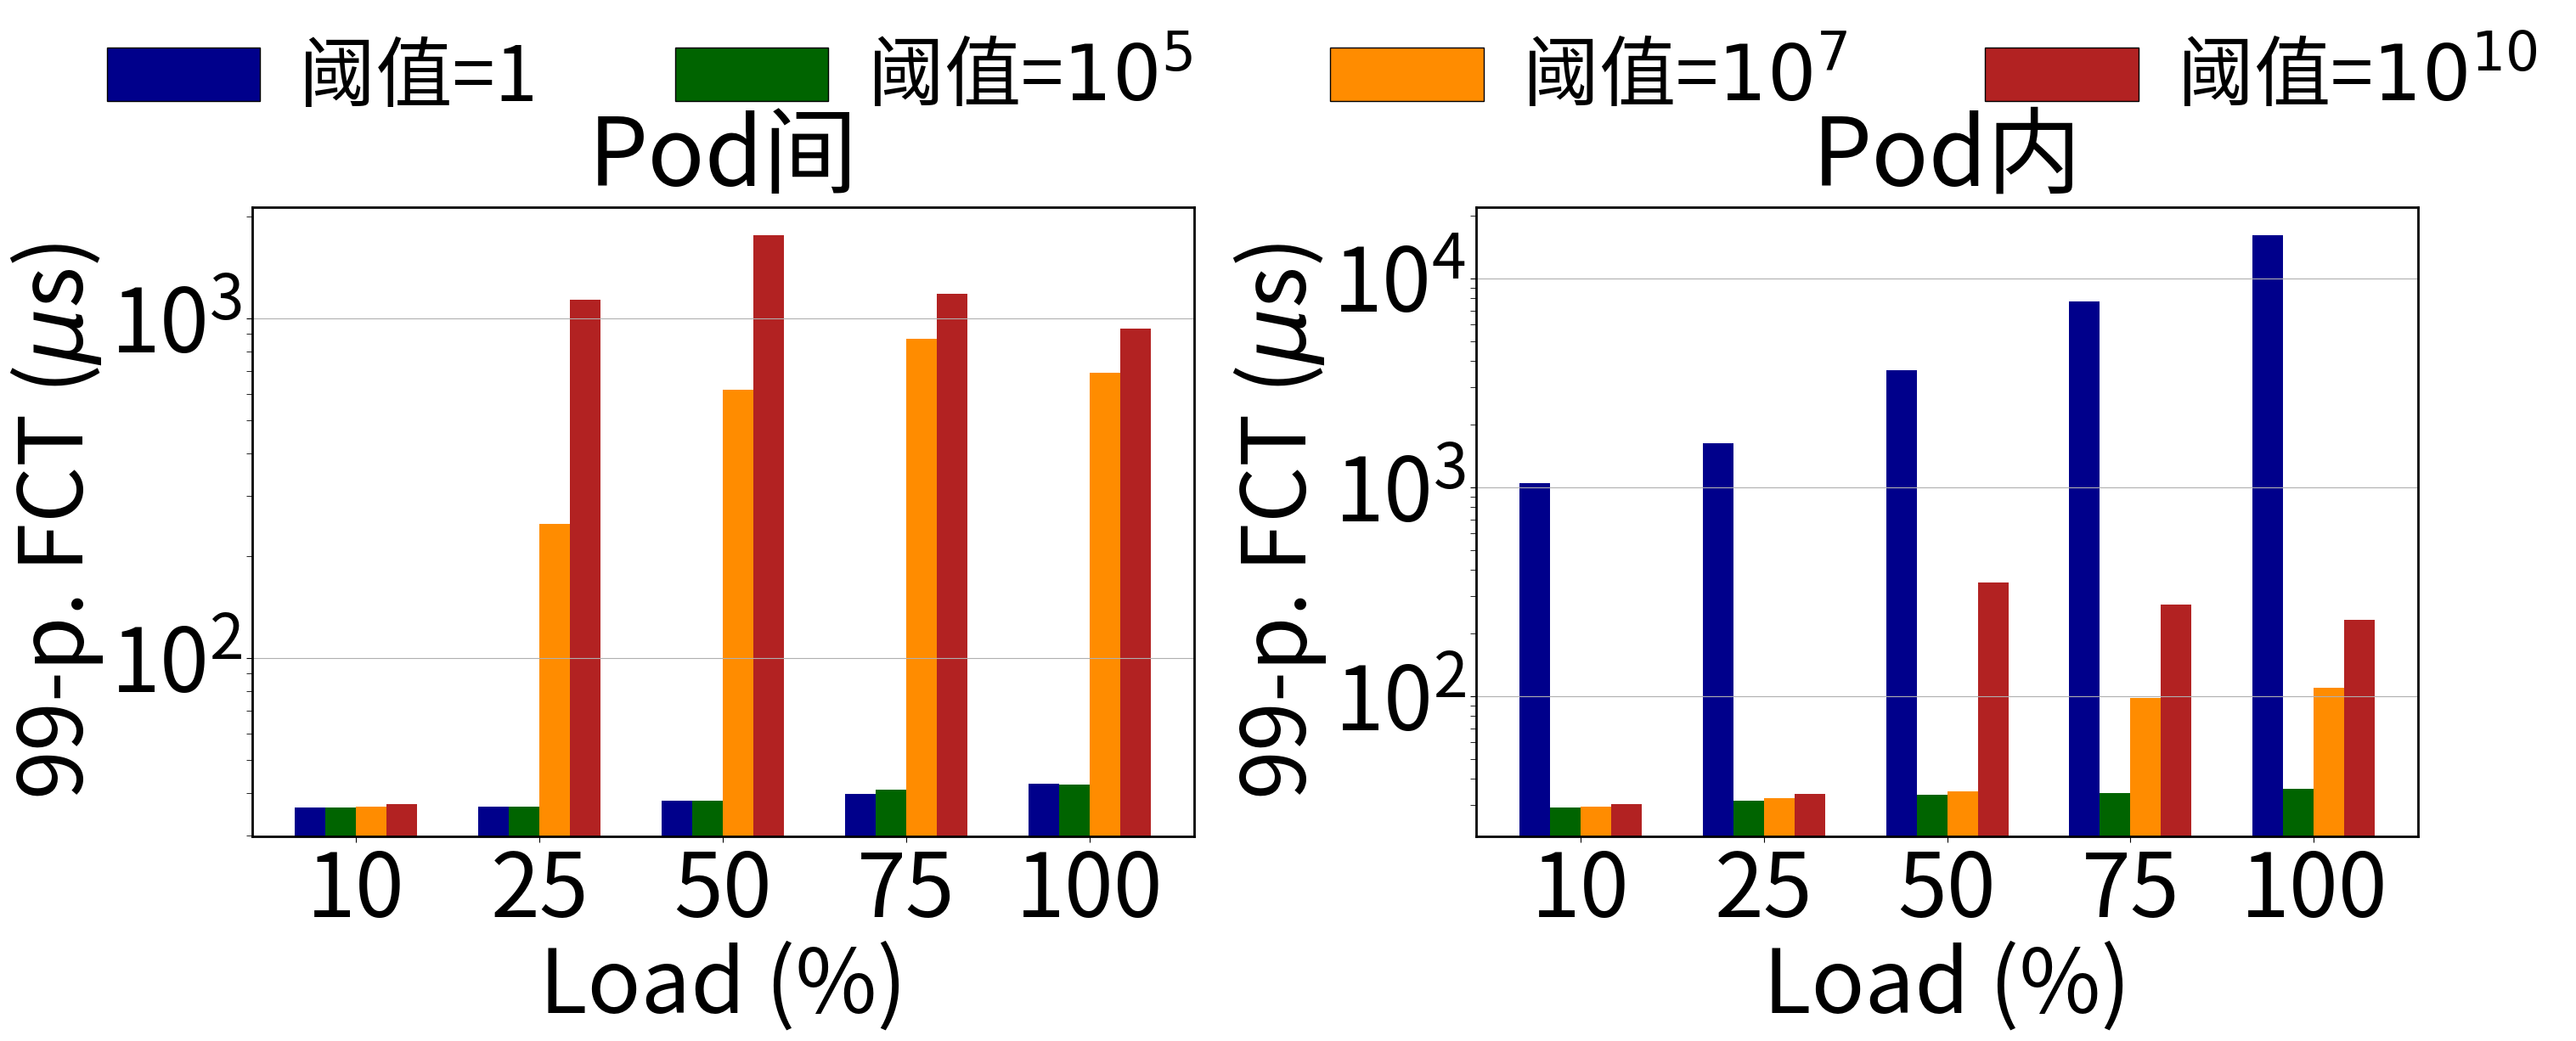

In [13]:
colors = ['white', 'white', 'white', 'white', 'white', 'white', 'white', 'white', 'white', 'white', 'white']
colors = ['darkblue', 'darkgreen', 'darkorange', 'firebrick', 'darkviolet', 'darkred', 'darkblue', 'darkgreen', 'darkorange', 'darkviolet', 'darkred']
# edge_colors = ['firebrick', 'firebrick', 'firebrick', 'firebrick', 'firebrick', 'firebrick', 'firebrick', 'firebrick']
# edge_colors = ['white', 'white', 'white', 'white']
# edge_colors = ['', '', '', '']
hatches = ['o', 'x', '+', '\\', 'x', '...', '-', '|', '\\', '。', '\\']
hatches = ['', '', '', '']
WIDTH = 0.05
my_figsize = [30,12]
my_fontsize = 75
mode = 'multipods'
plt.rc('font', family='Noto Sans CJK JP')

import os
fig_dir = '../FIGS/Thesis/Slot-Probing/'
if not os.path.exists(fig_dir):
	os.makedirs(fig_dir)
 

# fig, axs = plt.subplots(1, 2, figsize=my_figsize, gridspec_kw={
#         'width_ratios': [1, 1],  # 调整左右子图的宽度比例
#         'wspace': 0.3              # 设置子图之间的水平间距
#     })
fig = plt.figure(figsize=my_figsize, constrained_layout=False)
gs = fig.add_gridspec(
    nrows=2,  # 2行：1行给图例，1行给子图
    ncols=1,
    height_ratios=[0.05, 0.95],  # 图例区域占15%，主图区域占85%
    hspace=0  # 行间距为0
)
sub_gs = gs[1].subgridspec(1, 2, wspace=0.3)
ax1 = fig.add_subplot(sub_gs[0])
ax2 = fig.add_subplot(sub_gs[1])

# goodput_bar_plot(labels, ax1)
# plt.savefig(fig_dir + 'goodput.pdf')
# fct_bar_plot("99p", labels, WORKLOADS[0], ax2, flow_range='Mice', unit='us')
fct_bar_plot("99p", labels, workloads, ax1, flow_range='Mice', pods='multipods', unit='us')
fct_bar_plot("99p", labels, workloads, ax2, flow_range='Mice', pods='singlepod', unit='us')
# slowdown_bar_plot("Mean", labels, WORKLOADS[0], ax2, flow_range='Elephant', unit='us')

# 创建图例（放在第一行）
handles = [
    plt.Rectangle((0,0), 1, 1, 
        facecolor=colors[i], 
        hatch=hatches[i], 
        edgecolor='black') 
    for i in range(len(SCHEMES_label))
]

# 将图例放在顶部独立区域
leg = fig.legend(
    handles=handles,
    labels=SCHEMES_label,
    loc='upper center',
    ncol=4,  # 水平排列4个图例项
    bbox_to_anchor=(0.52, 1.05),  # 垂直位置调整
    fontsize=my_fontsize-10,
    frameon=False,
    handletextpad=0.5,
    columnspacing=1.8
)


# fig.subplots_adjust(top=0.90,  # 增加这个值使图上移
#                         bottom=0.2,  # 减少这个值使图上移
#                         left=0.1,
#                         right=0.99,
#                         wspace=0.2)
plt.subplots_adjust(
    top=0.85,  # 给顶部图例留出空间
    bottom=0.2,
    left=0.1,
    right=0.95,
)


plt.savefig(fig_dir + 'fct-split-pods.pdf')